Make a plot of planetary radius as a function of equilibrium temperature and investigate whether there is a clear transition where inflation becomes significant.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import csv

In [ ]:
# temps = []
# radii = []
# sm_as = []
# st_lums = []
# st_masss = []
# st_mets = []
# st_rads = []

# fluxes = []
# distances = []
# increase_percent = []


# tperr = []
# tnerr = []
# prperr = []
# prnerr = []
# sperr = []
# snerr = []
# lperr = []
# lnerr = []
# maperr = []
# manerr = []
# meperr = []
# menerr = []
# srperr = []
# srnerr = []
# # fperr = []
# # fnerr = []
# # dperr = []
# # dnerr = []
# # iperr = []
# # inerr = []

# with open("PSCompPars_2026(1485).csv", newline='') as file:
#     for line in file:
#         if not line.startswith("#"):  # first non-metadata line
#             header_line = line
#             break

#     reader = csv.DictReader(file, fieldnames=header_line.strip().split(","))
#     # print(reader.fieldnames)

#     for row in reader:
#         if row["pl_eqt"] and row["pl_radj"] and row["st_lum"] and row["st_mass"] and row["st_met"] and row["pl_orbsmax"] and row["st_rad"] and row["pl_eqterr1"] and row["pl_eqterr2"] and row["pl_radjerr1"] and row["pl_radjerr2"] and row["st_lumerr1"] and row["st_lumerr2"] and row["st_masserr1"] and row["st_masserr2"] and row["st_meterr1"] and row["st_meterr2"] and row["pl_orbsmaxerr1"] and row["pl_orbsmaxerr2"] and row["st_raderr1"] and row["st_raderr2"]:
#             temps.append(float(row["pl_eqt"]))
#             radii.append(float(row["pl_radj"]))
#             sm_as.append(float(row["pl_orbsmax"]))
#             st_lums.append(float(row["st_lum"]))
#             st_masss.append(float(row["st_mass"]))
#             st_mets.append(float(row["st_met"]))
#             st_rads.append(float(row["st_rad"]))
#             tperr.append(float(row["pl_eqterr1"]))
#             tnerr.append(float(row["pl_eqterr2"]))
#             prperr.append(float(row["pl_radjerr1"]))
#             prnerr.append(float(row["pl_radjerr2"]))
#             sperr.append(float(row["pl_orbsmaxerr1"]))
#             snerr.append(float(row["pl_orbsmaxerr2"]))
#             lperr.append(float(row["st_lumerr1"]))
#             lnerr.append(float(row["st_lumerr2"]))
#             maperr.append(float(row["st_masserr1"]))
#             manerr.append(float(row["st_masserr2"]))
#             meperr.append(float(row["st_meterr1"]))
#             menerr.append(float(row["st_meterr2"]))
#             srperr.append(float(row["st_raderr1"]))
#             srnerr.append(float(row["st_raderr2"]))


# for pl_rad, st_rad, sm_a in zip(radii, st_rads, sm_as):
#     dist = sm_a - (st_rad + pl_rad)
#     distances.append(dist)

# for temp, pl_rad, sm_a, name, st_lum, st_mass, st_met, st_rad, dist in zip(temps, radii, sm_as, st_lums, st_masss, st_mets, st_rads, distances):
#     if st_lum / (4 * np.pi * dist ** 2) > 1:
#         temps.remove(temp)
#         radii.remove(pl_rad)
#         sm_as.remove(sm_a)
#         st_lums.remove(st_lum)
#         st_masss.remove(st_mass)
#         st_mets.remove(st_met)
#         st_rads.remove(st_rad)
#         distances.remove(dist)

#     elif st_lum / (4 * np.pi * dist ** 2) < -0.8:
#         temps.remove(temp)
#         radii.remove(pl_rad)
#         sm_as.remove(sm_a)
#         st_lums.remove(st_lum)
#         st_masss.remove(st_mass)
#         st_mets.remove(st_met)
#         st_rads.remove(st_rad)
#         distances.remove(dist)

# for lum, dist in zip(st_lums, distances):
#     flux = lum / (4 * np.pi * (dist ** 2))
#     fluxes.append(flux)

# for temp, rad in zip(temps, radii):
#     exp_rad = (1.1 * temp ** 0.35) / 11 # /11 to convert to Jupiter Radius
#     increase = ((rad / exp_rad) - 1) * 100 # *100 to get a percentage
#     increase_percent.append(increase)


In [41]:

data = []

def to_float(value):
    try:
        return float(value)
    except:
        return None

with open("PSCompPars_2026(1485).csv", newline='') as file:
    for line in file:
        if not line.startswith("#"):  # first non-metadata line
            header_line = line
            break

    reader = csv.DictReader(file, fieldnames=header_line.strip().split(","))

    for row in reader:
        temp = to_float(row["pl_eqt"])
        tperr = to_float(row["pl_eqterr1"])
        tnerr = to_float(row["pl_eqterr2"])
        radius = to_float(row["pl_radj"])
        rperr = to_float(row["pl_radjerr1"])
        rnerr = to_float(row["pl_radjerr2"])
        sma = to_float(row["pl_orbsmax"])
        smperr = to_float(row["pl_orbsmaxerr1"])
        smnerr = to_float(row["pl_orbsmaxerr2"])
        st_lum = to_float(row["st_lum"])
        slperr = to_float(row["st_lumerr1"])
        slnerr = to_float(row["st_lumerr2"])
        st_mass = to_float(row["st_mass"])
        smperr = to_float(row["st_masserr1"])
        smnerr = to_float(row["st_masserr2"])
        st_met = to_float(row["st_met"])
        smperr = to_float(row["st_meterr1"])
        smnerr = to_float(row["st_meterr2"])
        st_rad = to_float(row["st_rad"])
        srperr = to_float(row["st_raderr1"])
        srnerr = to_float(row["st_raderr2"])

        if None not in (temp, tperr, tnerr, radius, rperr, rnerr, sma, smperr, smnerr, st_lum, slperr, slnerr, st_mass, smperr, smnerr, st_met, smperr, smnerr, st_rad, srperr, srnerr):
            data.append({
                "pl_temp" : temp,
                "temp_plus" : tperr,
                "temp_minus" : tnerr,

                "pl_rad" : radius,
                "pl_rad_plus" : rperr,
                "pl_rad_minus" : rnerr,

                "sma" : sma,
                "sma_plus" : smperr,
                "sma_minus" : smnerr,

                "st_lum" : st_lum,
                "lum_plus" : slperr,
                "lum_minus" : slnerr,

                "st_mass" : st_mass,
                "mass_plus" : smperr,
                "mass_minus" : smnerr,

                "st_met" : st_met,
                "met_plus" : smperr,
                "met_minus" : smnerr,

                "st_rad" : st_rad,
                "st_rad_plus" : srperr,
                "st_rad_minus" : srnerr
            })

        for d in data:
            if d["st_lum"] / (4 * np.pi * d["sma"] ** 2) < -1000:
                data.remove(d)


## Observed Data

temps = [d["pl_temp"] for d in data]
temps_plus = [d["temp_plus"] for d in data]
temps_minus = [abs(d["temp_minus"]) for d in data]

radii = [d["pl_rad"] for d in data]
radii_plus = [d["pl_rad_plus"] for d in data]
radii_minus = [abs(d["pl_rad_minus"]) for d in data]

smas = [d["sma"] for d in data]
smas_plus = [d["sma_plus"] for d in data]
smas_minus = [abs(d["sma_minus"]) for d in data]

lums = [d["st_lum"] for d in data]
lums_plus = [d["lum_plus"] for d in data]
lums_minus = [abs(d["lum_minus"]) for d in data]

st_masses = [d["st_mass"] for d in data]
masses_plus = [d["mass_plus"] for d in data]
masses_minus = [abs(d["mass_minus"]) for d in data]

st_mets = [d["st_met"] for d in data]
mets_plus = [d["met_plus"] for d in data]
mets_minus = [abs(d["met_minus"]) for d in data]

st_rads = [d["st_rad"] for d in data]
srads_plus = [d["st_rad_plus"] for d in data]
srads_minus = [abs(d["st_rad_minus"]) for d in data]

## Calculated Information from Observed Data

fluxes = [
    d["st_lum"] / (4 * np.pi * d["sma"] ** 2)
    for d in data
]

increase_cents = [
    ((d["pl_rad"] / ((1.1 * d["pl_temp"] ** 0.35) / 11)) -1) * 100
    for d in data
]


In [33]:
# a = min(fluxes)
# print(a)
# print()


In [8]:
J_temp = 122
J_rad = 1

In [9]:
def plot1(temp, rad):
    plt.figure(figsize=(12,8))
    plt.scatter(temp, rad, s=10, label="Hot Jupiter")

    plt.scatter(J_temp, J_rad, color="red", s=10, label="Jupiter")

    x = np.linspace(min(temp), max(temp), 200)
    y = (1.1 * x ** 0.35) / 11
    plt.plot(x, y, linestyle="-", color="black", label="Edmonson Et al.")

    plt.xlabel("Equilibrium Temperature (°K)")
    plt.ylabel("Planetary Radius ($J_{rad}$)")
    plt.title("Figure 1")

    plt.legend()
    plt.show()


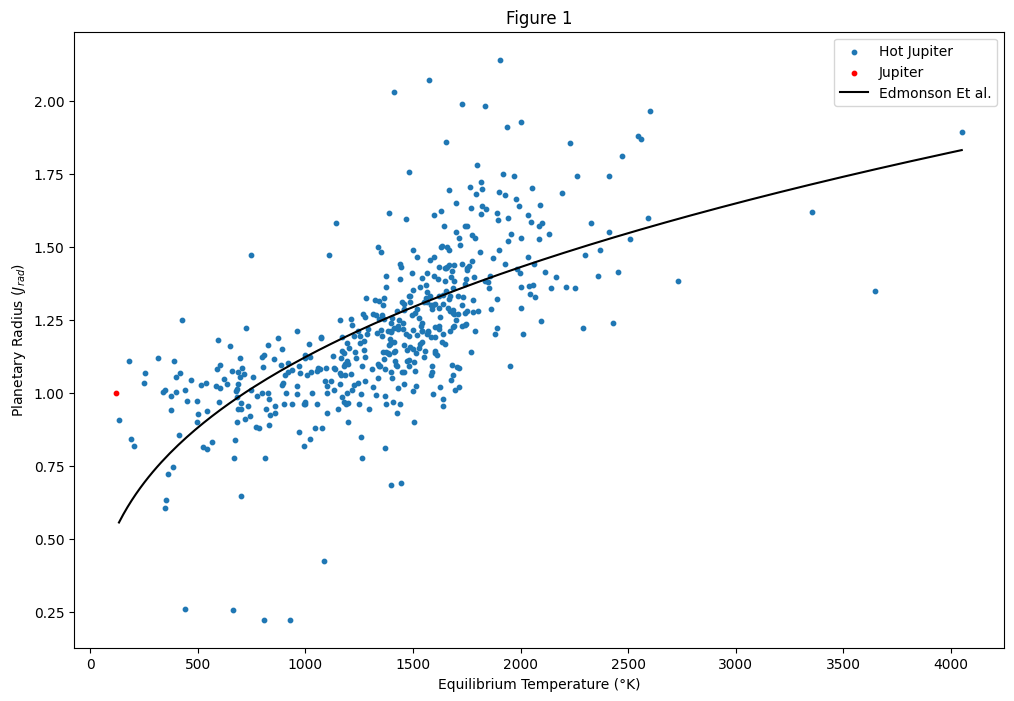

In [34]:
plot1(temps, radii)

How does the degree of inflation depend on incident flux?

In [12]:
def plot2(xaxis, yaxis, xname, yname, a):
    plt.figure(figsize=(12,8))
    plt.scatter(xaxis, yaxis, s=10)

    plt.xlabel(xname)
    plt.ylabel(yname)
    plt.title(f"Figure {a}")

    plt.show()


<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\macau\AppData\Local\Temp\ipykernel_23700\1448447375.py:1: SyntaxWarning: invalid escape sequence '\c'
  plot2(fluxes, increase_cents, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Degree of Inflation from Expected Value (%)", 2)


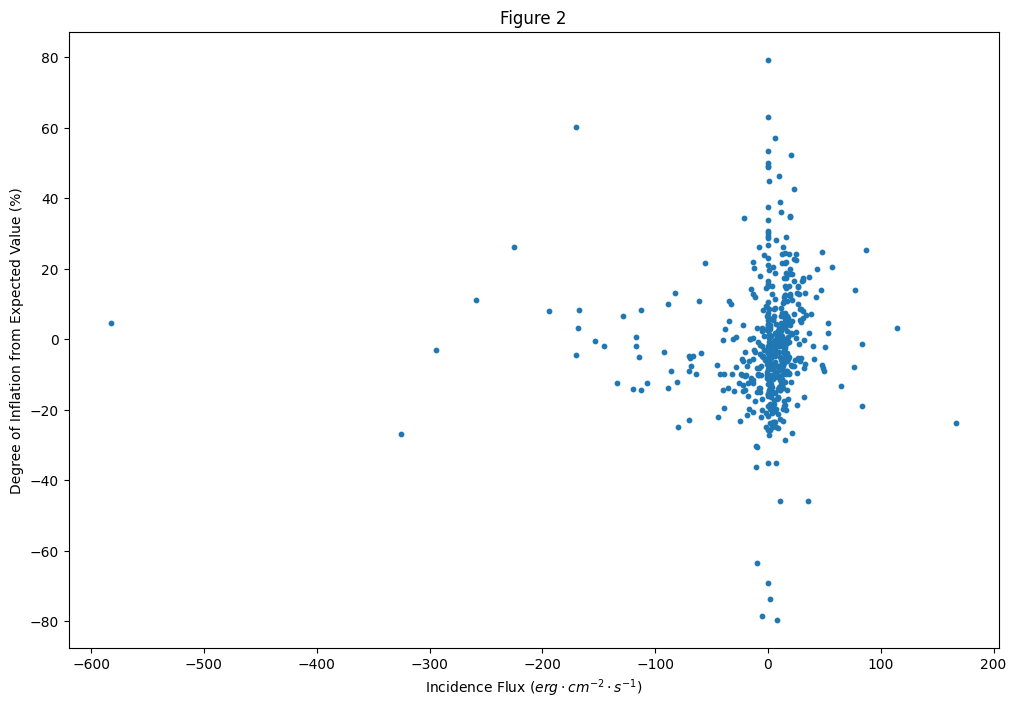

In [30]:
plot2(fluxes, increase_cents, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Degree of Inflation from Expected Value (%)", 2)

Are there correlations with host star properties such as mass or metallicity?

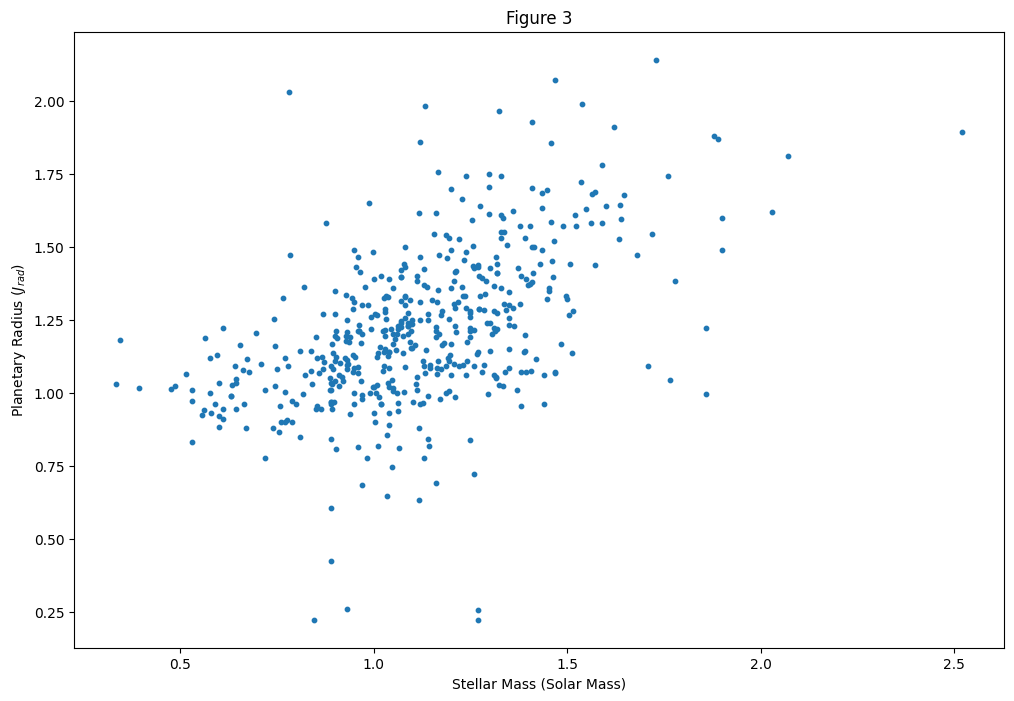

In [35]:
plot2(st_masses, radii, "Stellar Mass (Solar Mass)", "Planetary Radius ($J_{rad}$)", 3)

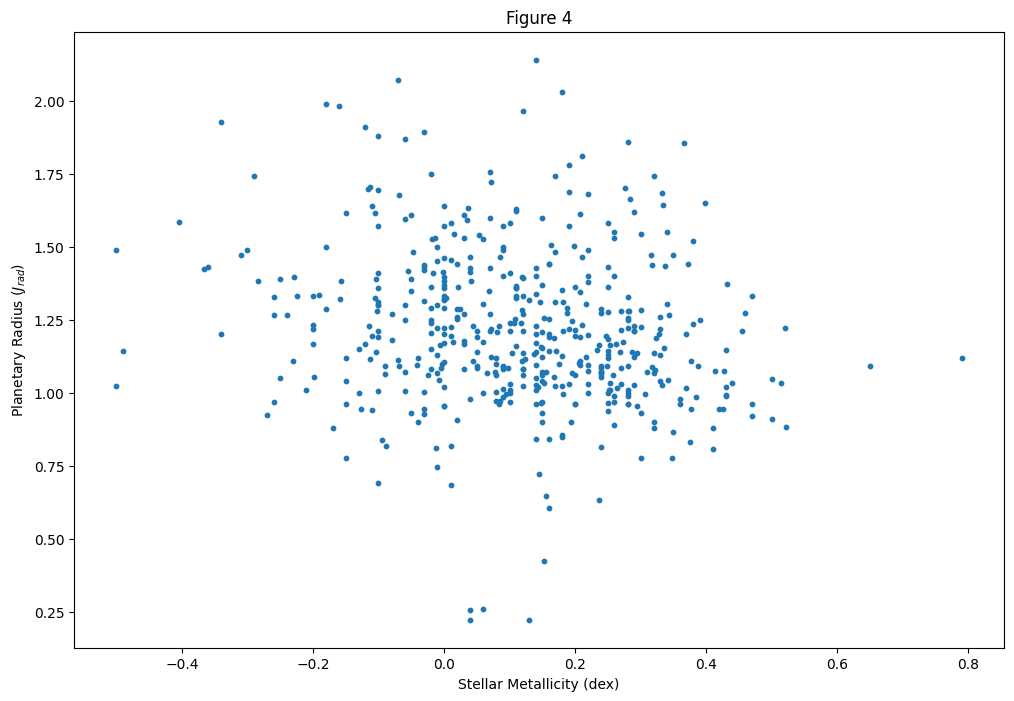

In [36]:
plot2(st_mets, radii, "Stellar Metallicity (dex)", "Planetary Radius ($J_{rad}$)", 4)

How large are the observational uncertainties, and how do they affect your conclusions?

In [52]:

def plot3(xaxis, yaxis, xname, yname, xerr, yerr, a):
    plt.figure(figsize=(12,8))
    plt.errorbar(xaxis, yaxis,
                 xerr, yerr,
                 fmt="o", markersize=4, capsize=3)

    plt.xlabel(xname)
    plt.ylabel(yname)
    plt.title(f"Figure {a}")

    plt.show()

In [ ]:
print(max(temps_plus))
print(min(temps_minus))
print()
print(max(radii_plus))
print(min(radii_minus))

180.0
1.5


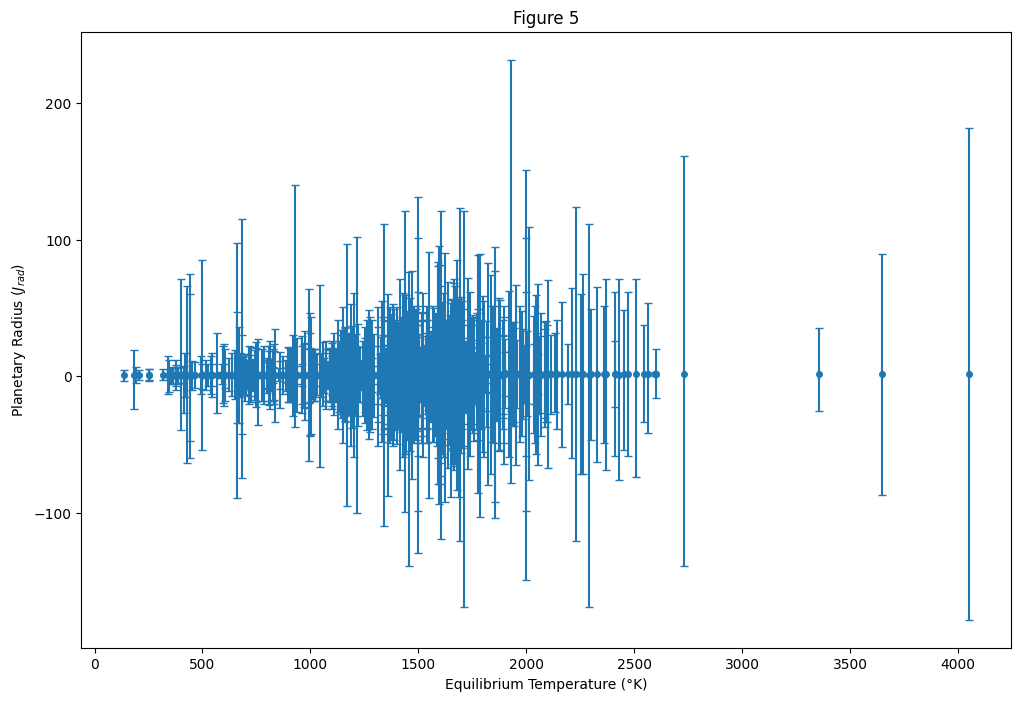

In [53]:
terr = [temps_plus, temps_minus]
prerr = [radii_plus, radii_minus]

plot3(temps, radii, "Equilibrium Temperature (°K)", "Planetary Radius ($J_{rad}$)", terr, prerr, 5)